In [3]:
#Load DataSet
import pandas as pd
df = pd.read_csv("C:/Users/yadav/Downloads/Vehicle_Insurance.csv")

In [2]:
df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [7]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [11]:
df.shape

(381109, 12)

In [5]:
print(df.dtypes)

numerical_cols = ['Age', 'Region_Code', 'Annual_Premium', 
                  'Policy_Sales_Channel', 'Vintage']
print("Numerical Columns:", numerical_cols)

categorical_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']
print("Categorical Columns:", categorical_cols)

binary_cols = ['Driving_License', 'Previously_Insured', 'Response']
print("Binary Columns:", binary_cols)

id                        int64
Gender                   object
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age              object
Vehicle_Damage           object
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object
Numerical Columns: ['Age', 'Region_Code', 'Annual_Premium', 'Policy_Sales_Channel', 'Vintage']
Categorical Columns: ['Gender', 'Vehicle_Age', 'Vehicle_Damage']
Binary Columns: ['Driving_License', 'Previously_Insured', 'Response']


In [9]:
print(df.isnull().sum())

num_cols = ['Age', 'Region_Code', 'Annual_Premium', 
            'Policy_Sales_Channel', 'Vintage']

for col in num_cols:
    df[col].fillna(df[col].mean())

cat_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0])

Q1 = df['Annual_Premium'].quantile(0.25)
Q3 = df['Annual_Premium'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Annual_Premium'] >= lower_bound) & 
        (df['Annual_Premium'] <= upper_bound)]

print("Outliers removed successfully")

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64
Outliers removed successfully


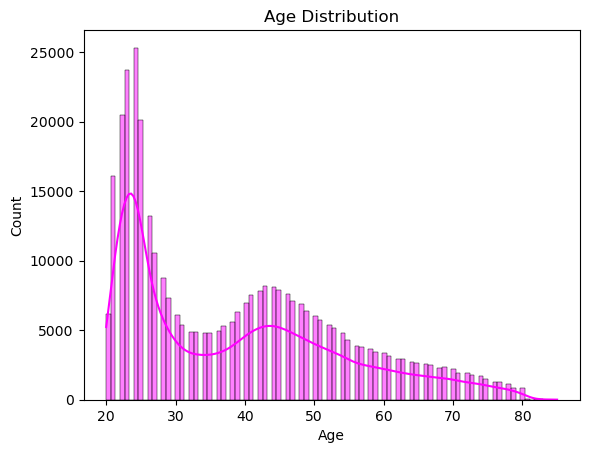

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df['Age'], kde=True, color = 'magenta' )
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

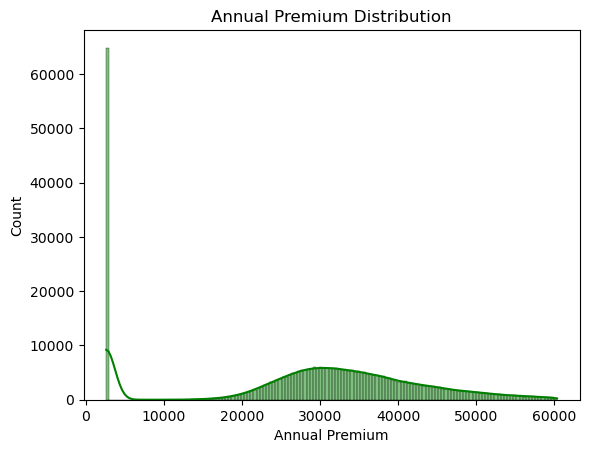

In [25]:
plt.figure()
sns.histplot(df['Annual_Premium'], kde=True, color = 'green')
plt.title("Annual Premium Distribution")
plt.xlabel("Annual Premium")
plt.ylabel("Count")
plt.show()

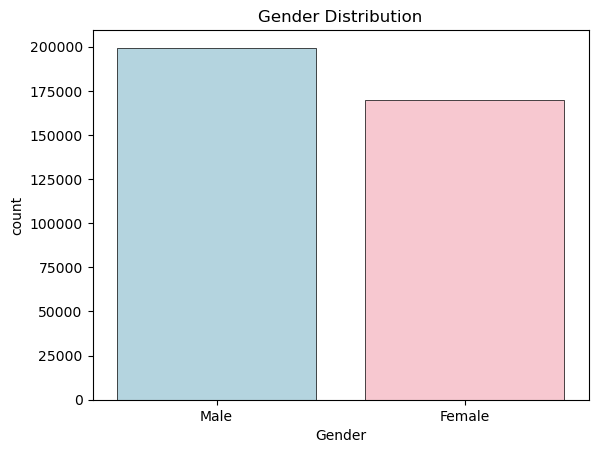

In [45]:
plt.figure()
colors = ['lightblue', 'pink']

sns.countplot(x='Gender', hue = 'Gender', data=df, 
              palette=colors, edgecolor='black', linewidth=0.5, legend = False)

plt.title("Gender Distribution")
plt.show()

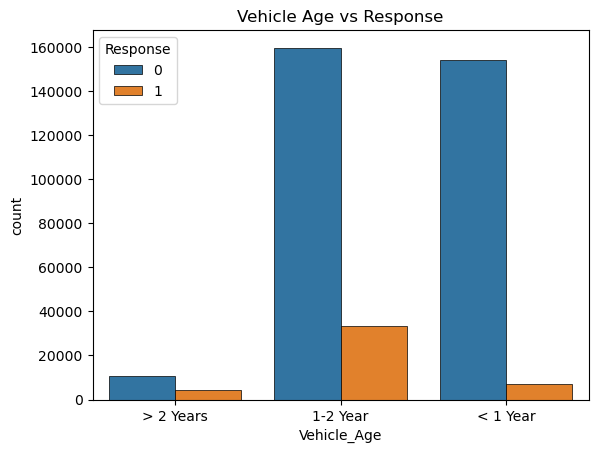

In [49]:
plt.figure()
sns.countplot(x='Vehicle_Age', hue='Response', data=df, edgecolor = 'black', linewidth = 0.5)
plt.title("Vehicle Age vs Response")
plt.show()

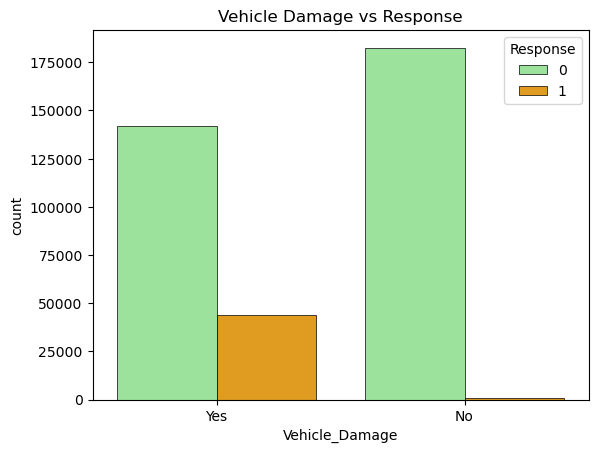

In [57]:
plt.figure()
colors = ['lightGreen','Orange']
sns.countplot(x='Vehicle_Damage', hue='Response', palette = colors, data=df, edgecolor = 'black', linewidth = 0.5)
plt.title("Vehicle Damage vs Response")
plt.show()

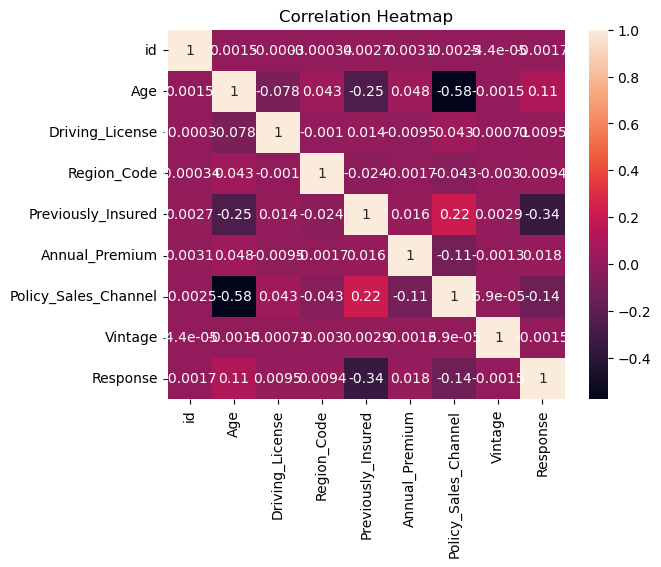

In [59]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

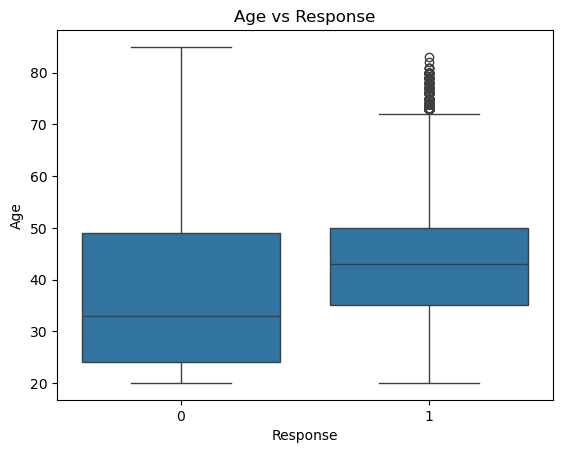

In [69]:
plt.figure()
sns.boxplot(x='Response', y='Age', data=df)
plt.title("Age vs Response")
plt.show()

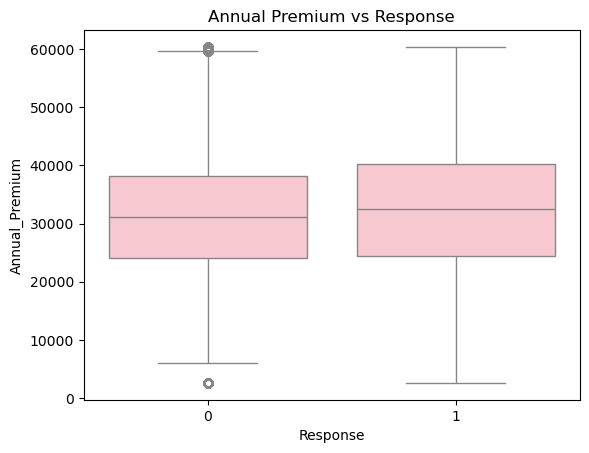

In [73]:
plt.figure()
sns.boxplot(x='Response', y='Annual_Premium', data=df, color = 'pink')
plt.title("Annual Premium vs Response")
plt.show()

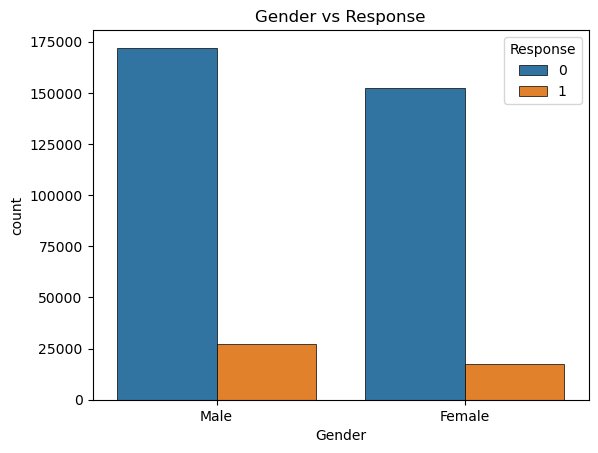

In [77]:
plt.figure()
sns.countplot(x='Gender', hue='Response', data=df, edgecolor = 'black', linewidth = 0.5)
plt.title("Gender vs Response")
plt.show()

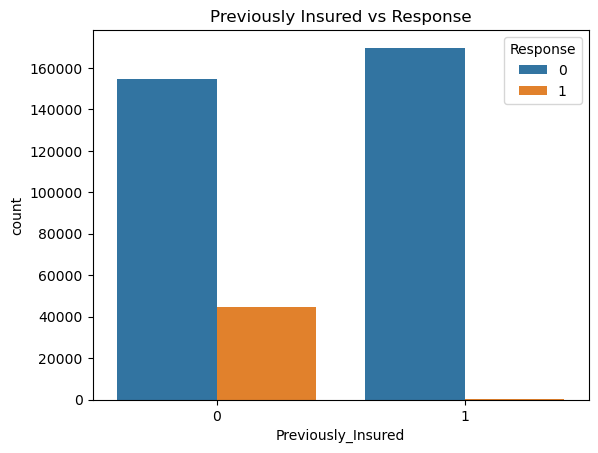

In [89]:
plt.figure()
sns.countplot(x='Previously_Insured', hue='Response', data=df)
plt.title("Previously Insured vs Response")
plt.show()

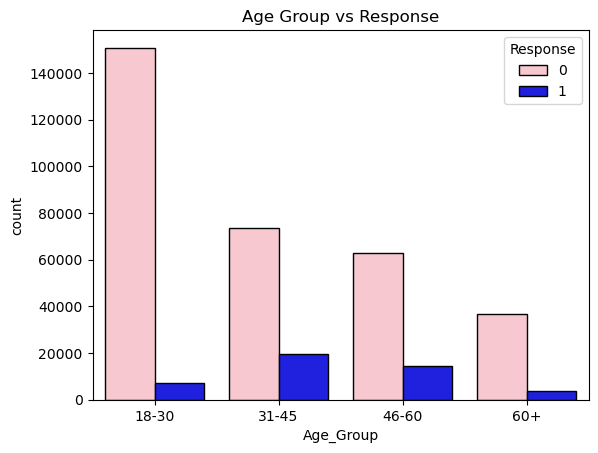

In [93]:
plt.figure()

sns.countplot(x='Age_Group', hue='Response', data=df,
              palette=['pink', 'blue'], edgecolor='black')

plt.title("Age Group vs Response")
plt.show()

Response          0          1
Gender                        
Female    89.686709  10.313291
Male      86.263028  13.736972


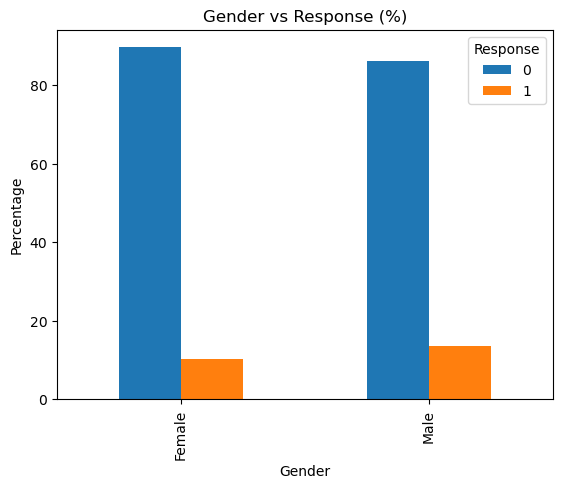

In [101]:
gender_response = pd.crosstab(df['Gender'], df['Response'], normalize='index') * 100
print(gender_response)

gender_response.plot(kind='bar')
plt.title("Gender vs Response (%)")
plt.ylabel("Percentage")
plt.show(

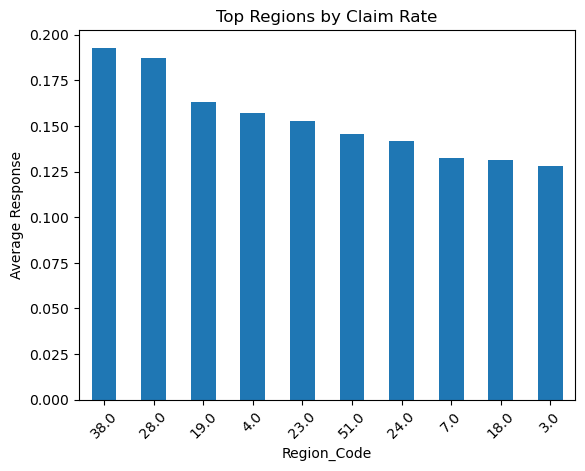

In [105]:
region_avg = df.groupby('Region_Code')['Response'].mean().sort_values(ascending=False)

plt.figure()
region_avg.head(10).plot(kind='bar')
plt.title("Top Regions by Claim Rate")
plt.ylabel("Average Response")
plt.xticks(rotation=45)
plt.show()

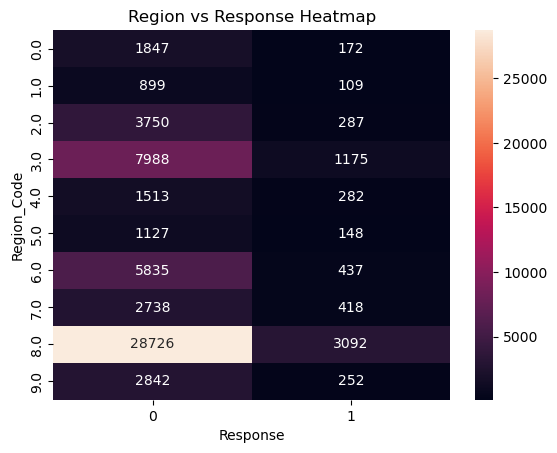

In [107]:
region_heat = pd.crosstab(df['Region_Code'], df['Response'])

plt.figure()
sns.heatmap(region_heat.head(10), annot=True, fmt='d')
plt.title("Region vs Response Heatmap")
plt.show()

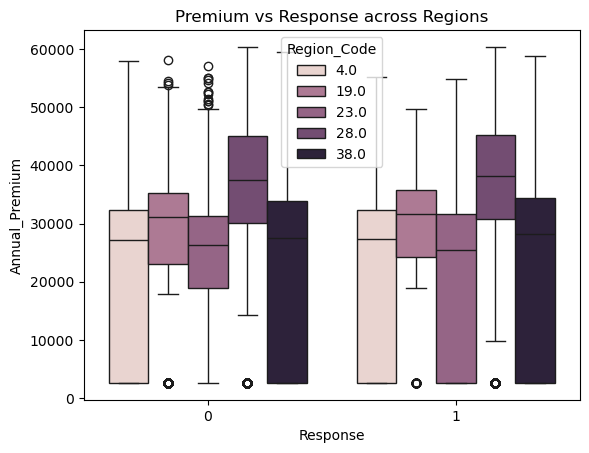

In [109]:
plt.figure()
sns.boxplot(x='Response', y='Annual_Premium', hue='Region_Code',
            data=df[df['Region_Code'].isin(region_avg.head(5).index)])
plt.title("Premium vs Response across Regions")
plt.show()

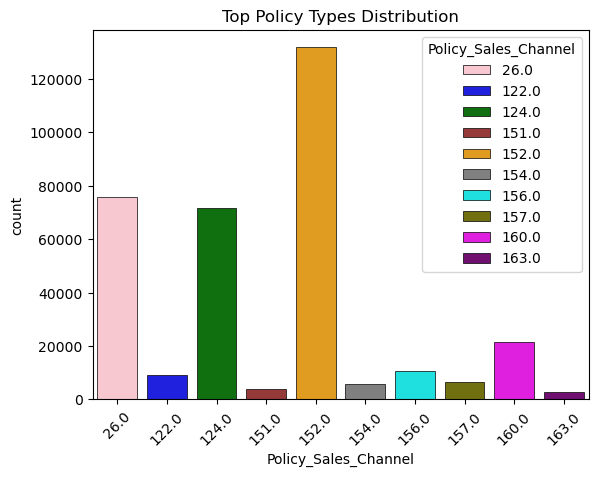

In [133]:
top_policy = df['Policy_Sales_Channel'].value_counts().head(10).index

plt.figure()
colors = ['pink','blue','green','brown','orange','grey','cyan','olive','magenta','purple']
sns.countplot(x='Policy_Sales_Channel', hue='Policy_Sales_Channel',data=df[df['Policy_Sales_Channel'].isin(top_policy)],
              palette = colors, edgecolor = 'black', linewidth = 0.5)
plt.title("Top Policy Types Distribution")
plt.xticks(rotation=45)
plt.show()

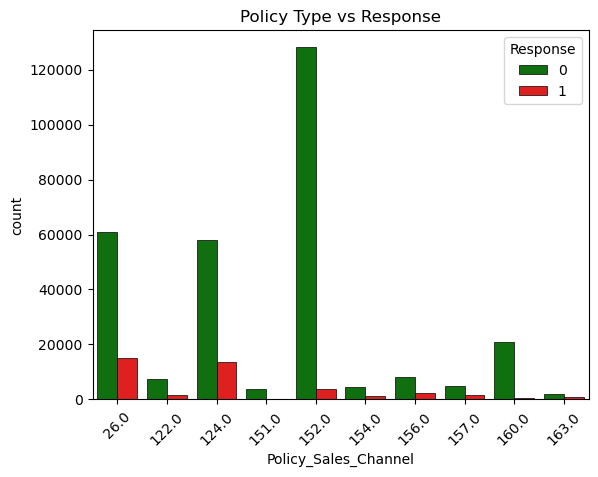

In [137]:
plt.figure()
sns.countplot(x='Policy_Sales_Channel', hue='Response', 
              data=df[df['Policy_Sales_Channel'].isin(top_policy)], palette = ['green', 'red'],edgecolor = 'black', linewidth = 0.5)
plt.title("Policy Type vs Response")
plt.xticks(rotation=45)
plt.show()

In [115]:
policy_response = pd.crosstab(df['Policy_Sales_Channel'], df['Response'], normalize='index') * 100
print(policy_response.loc[top_policy])

Response                      0          1
Policy_Sales_Channel                      
152.0                 97.123781   2.876219
26.0                  80.273525  19.726475
124.0                 81.042694  18.957306
160.0                 97.808960   2.191040
156.0                 78.488427  21.511573
122.0                 82.787866  17.212134
157.0                 73.175513  26.824487
154.0                 75.328218  24.671782
151.0                 96.815789   3.184211
163.0                 69.659769  30.340231


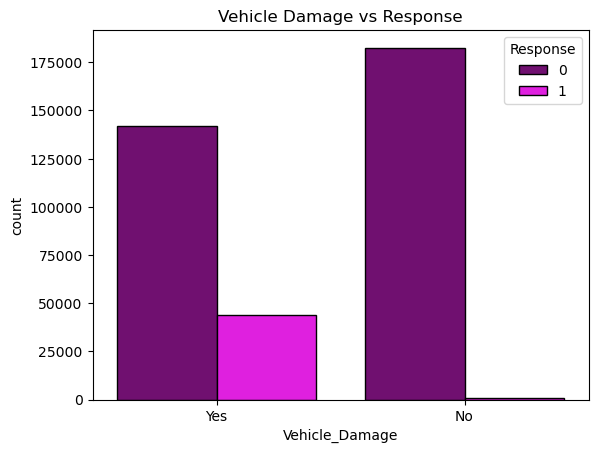

Response                0          1
Vehicle_Damage                      
No              99.475482   0.524518
Yes             76.329962  23.670038


In [141]:
plt.figure()
sns.countplot(x='Vehicle_Damage', hue='Response', data=df,
              palette=['purple', 'magenta'], edgecolor='black')
plt.title("Vehicle Damage vs Response")
plt.show()

damage_response = pd.crosstab(df['Vehicle_Damage'], df['Response'], normalize='index') * 100
print(damage_response)

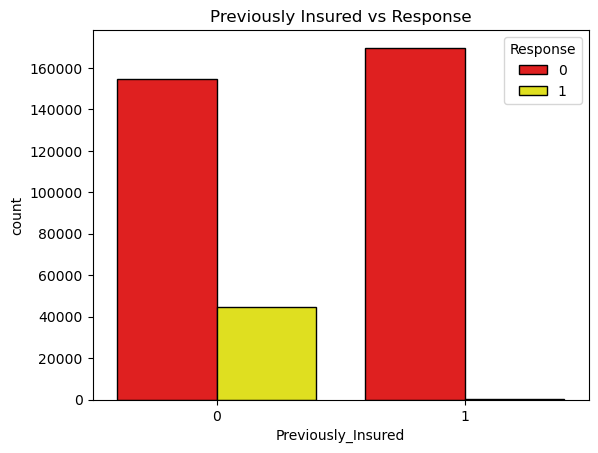

Response                    0          1
Previously_Insured                      
0                   77.556035  22.443965
1                   99.909331   0.090669


In [149]:
plt.figure()
sns.countplot(x='Previously_Insured', hue='Response', data=df,
              palette=['red', 'yellow'], edgecolor='black')
plt.title("Previously Insured vs Response")
plt.show()

insured_response = pd.crosstab(df['Previously_Insured'], df['Response'], normalize='index') * 100
print(insured_response)

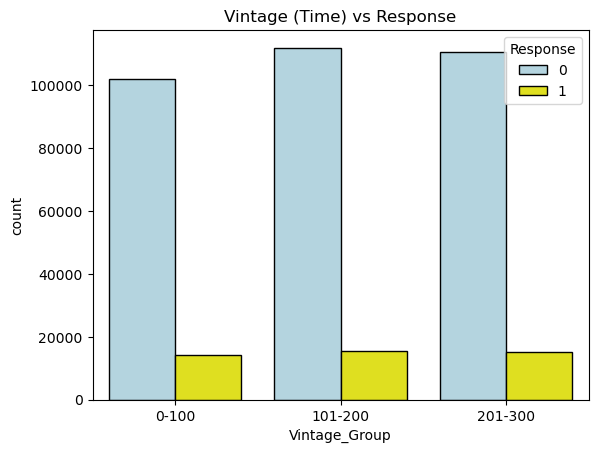

Response               0          1
Vintage_Group                      
0-100          87.811222  12.188778
101-200        87.844675  12.155325
201-300        87.854148  12.145852


In [153]:
df['Vintage_Group'] = pd.cut(df['Vintage'], 
                            bins=[0, 100, 200, 300], 
                            labels=['0-100', '101-200', '201-300'])

plt.figure()
sns.countplot(x='Vintage_Group', hue='Response', data=df,
              palette=['lightblue', 'yellow'], edgecolor='black')
plt.title("Vintage (Time) vs Response")
plt.show()

vintage_response = pd.crosstab(df['Vintage_Group'], df['Response'], normalize='index') * 100
print(vintage_response)